<h1 style="color:red;">GRAPHICAL USER INTERFACE for Random Forest to Predict the OVERALL GAS HOLDUP for SLURRY BUBBLE COLUMN REACTORS</h1>

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


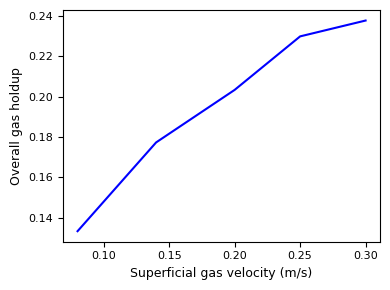

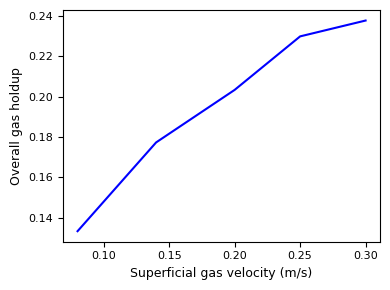

In [1]:
import numpy as np
import pickle
import tkinter as tk
from tkinter import filedialog, messagebox
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# Load the saved SVR model
with open('RFT_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the saved training limits
try:
    with open('training_limits.pkl', 'rb') as f:
        training_limits = pickle.load(f)
except FileNotFoundError:
    messagebox.showerror("Error", "Could not find 'training_limits.pkl'.")
    sys.exit(1)

# Initialize the main window
root = tk.Tk()
root.title("SBCR-RFT-GVOF GUI")
root.resizable(True, True) # Allow resizing if needed

# Define a custom style for bold and blue labels (Reduced font size)
bold_blue_style = {
    "font": ("Helvetica", 10, "bold"),
    "fg": "blue"
}

# Add a label for the GUI statement
statement_label = tk.Label(root, text="Slurry Bubble Column Gas Holdup (Random Forest Model)", font=("Helvetica", 12, "bold"), fg="green")
statement_label.grid(row=0, column=0, columnspan=2, pady=(10, 10))

# Names for inputs and outputs
input_names = [
    "Temperature (K)", "Pressure (Pascal)", "Superficial gas velocity (m/s)", "Gas molecular weight (kg/kmol)", 
    "Liquid density (kg/m³)", "Liquid viscosity (Pa·s)", "Liquid surface tension (N/m)", "Gas density (kg/m³)", 
    "Column diameter (m)", "Sparger open area (%)", "Particle diameter (m)", "Solid density (kg/m³)", 
    "Solid loading (%)", "Aspect ratio", "PPMN", "PSBC", "RSC"
]
output_names = ["Overall gas holdup"]

# Create a dedicated frame for the inputs to keep them compact
input_frame = tk.Frame(root)
input_frame.grid(row=1, column=0, padx=10, sticky="nw")

inputs_label = tk.Label(input_frame, text="INPUTS", **bold_blue_style)
inputs_label.grid(row=0, column=0, columnspan=4, pady=(0, 5))

# Create and place input fields in TWO columns to save vertical space
inputs = []
for i, name in enumerate(input_names):
    # Calculate row and column for a 2-column layout
    r = (i % 9) + 1  # 9 items per column
    c = (i // 9) * 2 # Shift to column 2 for items 10-17
    
    label = tk.Label(input_frame, text=name + ":", **bold_blue_style)
    label.grid(row=r, column=c, sticky="e", padx=(5, 2), pady=2)
    entry = tk.Entry(input_frame, width=12)
    entry.grid(row=r, column=c+1, padx=(0, 10), pady=2, sticky="w")
    inputs.append(entry)

# Create a dedicated frame for buttons and outputs
control_frame = tk.Frame(root)
control_frame.grid(row=2, column=0, pady=10, padx=10, sticky="w")

# Create a frame specifically for the plot on the right side
plot_frame = tk.Frame(root)
plot_frame.grid(row=1, column=1, rowspan=2, padx=10, pady=10, sticky="n")

# Output label setup
output_labels = []
for i, name in enumerate(output_names):
    label = tk.Label(control_frame, text="", font=("Helvetica", 11, "bold"), justify=tk.LEFT)
    label.grid(row=1, column=1, padx=(10, 10), pady=5, sticky="w")
    output_labels.append(label)

def predict(inputs):
    try:
        input_values = np.array([float(entry.get()) for entry in inputs])

        if len(input_values) != 17:
            raise ValueError("Please enter exactly 17 input values.")

        # VALIDATION CHECK: Compare inputs against the loaded boundaries
        for i, val in enumerate(input_values):
            min_val, max_val = training_limits[i]
            
            if val < min_val or val > max_val:
                name = input_names[i]
                raise ValueError(f"Value for '{name}' ({val}) is outside the safe training range ({min_val:.4f} to {max_val:.4f}).")

        # Make prediction if all checks pass
        prediction = model.predict([input_values])

        output_labels[0].config(text=f"{output_names[0]}: {prediction[0]:.4f}", fg="red")

        if hasattr(root, 'plot_canvas'):
            root.plot_canvas.get_tk_widget().destroy()

    except ValueError as e:
        messagebox.showerror("Input Error", str(e))

# Function to handle loading Excel file and prediction
def load_excel_file_and_predict():
    try:
        # Open file dialog to select Excel file
        file_path = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx;*.xls")])
        if file_path:
            # Load data from Excel file
            df = pd.read_excel(file_path)
            
            # Ensure there are exactly 17 inputs
            if df.shape[1] != 17:
                raise ValueError("The loaded Excel file should have exactly 17 input columns.")

            # Make predictions for all rows
            predictions = model.predict(df.values)

            # Clear previous output labels to keep the GUI clean
            for label in output_labels:
                label.config(text="")

            # Show a pop-up confirming success instead of printing a list to the screen
            messagebox.showinfo("Success", f"Successfully generated {len(predictions)} predictions from the Excel file.")

            # Clear previous plot (if any)
            if hasattr(root, 'plot_canvas'):
                root.plot_canvas.get_tk_widget().destroy()

    except ValueError as e:
        messagebox.showerror("Input Error", str(e))
    except Exception as e:
        messagebox.showerror("Error", f"Failed to load and predict: {str(e)}")

def plot_sgv_vs_ogh():
    try:
        file_path = filedialog.askopenfilename(filetypes=[("Excel files", "*.xlsx;*.xls")])
        if file_path:
            df = pd.read_excel(file_path)
            if df.shape[1] != 17:
                raise ValueError("The loaded Excel file should have exactly 17 input columns.")
            
            sgv_values = df.iloc[:, 2].values.astype(float) 
            predictions = model.predict(df.values)

            if hasattr(root, 'plot_canvas'):
                root.plot_canvas.get_tk_widget().destroy()

            # Reduced figure size for the plot
            fig, ax = plt.subplots(figsize=(4, 3)) 
            ax.plot(sgv_values, predictions, color='blue')
            ax.set_xlabel('Superficial gas velocity (m/s)', fontsize=9)
            ax.set_ylabel('Overall gas holdup', fontsize=9)
            ax.tick_params(axis='both', which='major', labelsize=8)
            fig.tight_layout()

            plot_canvas = FigureCanvasTkAgg(fig, master=plot_frame)
            plot_canvas.draw()
            plot_canvas.get_tk_widget().pack()
            root.plot_canvas = plot_canvas 

    except ValueError as e:
        messagebox.showerror("Input Error", str(e))
    except Exception as e:
        messagebox.showerror("Plotting Error", str(e))

# Buttons arranged in a grid inside the control frame
predict_button = tk.Button(control_frame, text="Predict from Inputs", command=lambda: predict(inputs))
predict_button.grid(row=1, column=0, pady=5, sticky="ew")

load_excel_button = tk.Button(control_frame, text="Load Excel and Predict", command=load_excel_file_and_predict)
load_excel_button.grid(row=2, column=0, pady=5, sticky="ew")

plot_button = tk.Button(control_frame, text="Plot SGV vs OGH", command=plot_sgv_vs_ogh)
plot_button.grid(row=3, column=0, pady=5, sticky="ew")

root.mainloop()